In [4]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../database/mutual_fund.db")

funds = pd.read_sql("SELECT * FROM dim_fund", conn)
nav = pd.read_sql("SELECT * FROM fact_nav", conn)
aum = pd.read_sql("SELECT * FROM fact_aum", conn)
sip = pd.read_sql("SELECT * FROM fact_sip", conn)

print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)

conn.close()

Funds: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)


Matplotlib is building the font cache; this may take a moment.


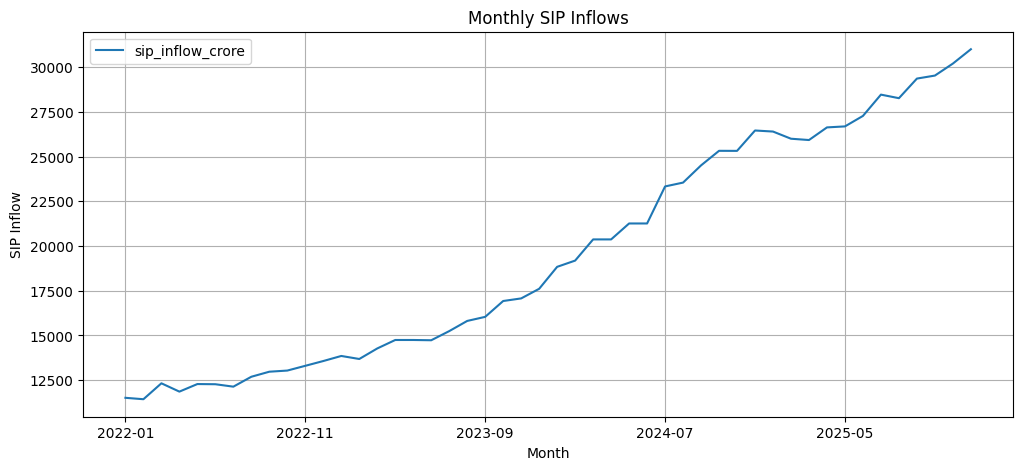

In [5]:
import matplotlib.pyplot as plt

sip.plot(
    x=sip.columns[0],
    y=sip.columns[1],
    figsize=(12,5)
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow")
plt.grid(True)

plt.show()

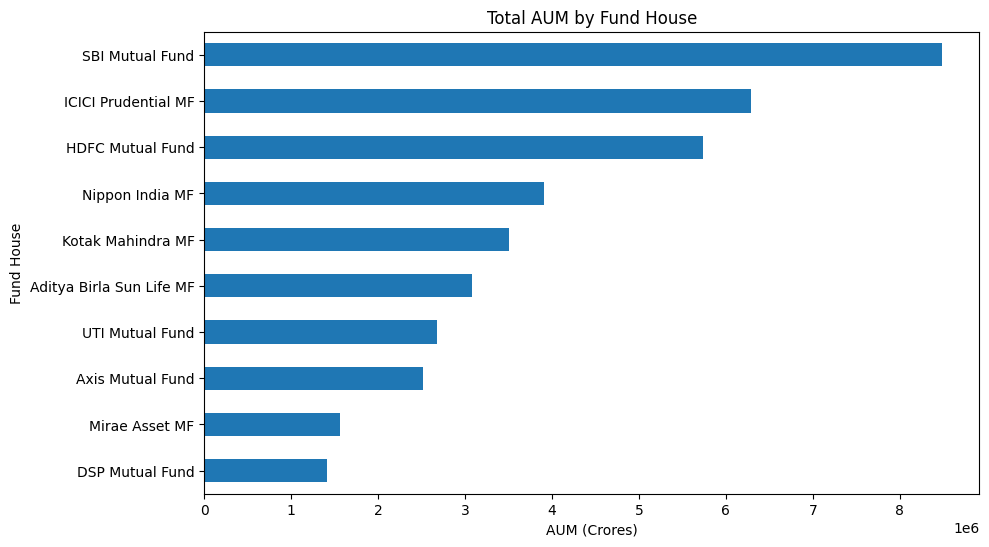

In [6]:
import matplotlib.pyplot as plt

aum.groupby("fund_house")["aum_crore"].sum().sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Total AUM by Fund House")
plt.xlabel("AUM (Crores)")
plt.ylabel("Fund House")

plt.show()

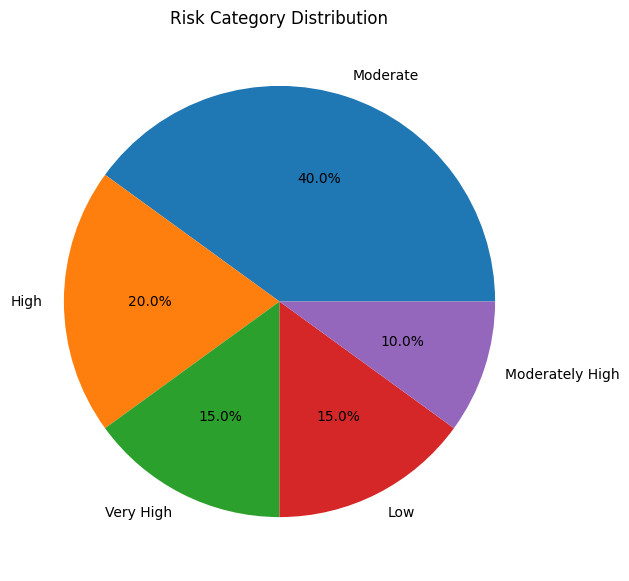

In [7]:
funds["risk_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Risk Category Distribution")
plt.ylabel("")

plt.show()

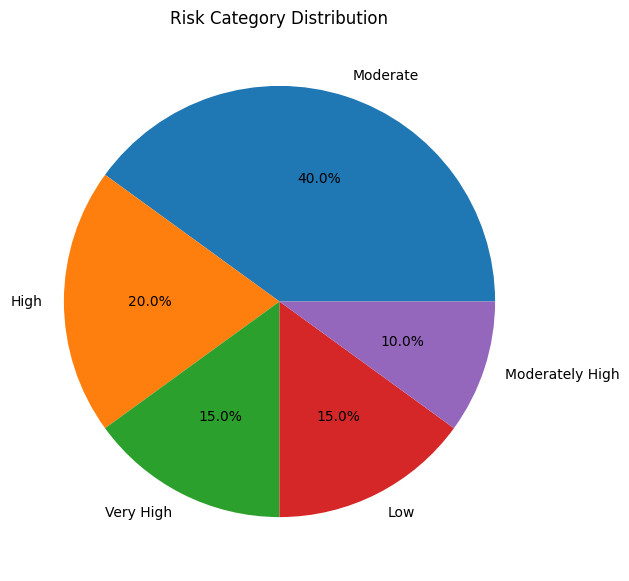

In [8]:
funds["risk_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Risk Category Distribution")
plt.ylabel("")

plt.show()

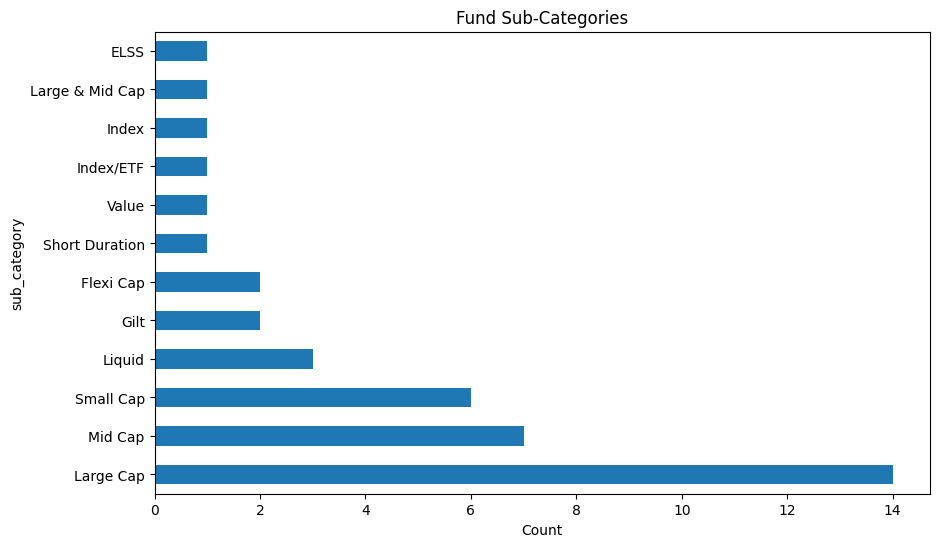

In [ ]:
funds["sub_category"].value_counts().plot(
    kind="barh",
    figsize=(10,6)
)s

plt.title("Fund Sub-Categories")
plt.xlabel("Count")

plt.show()

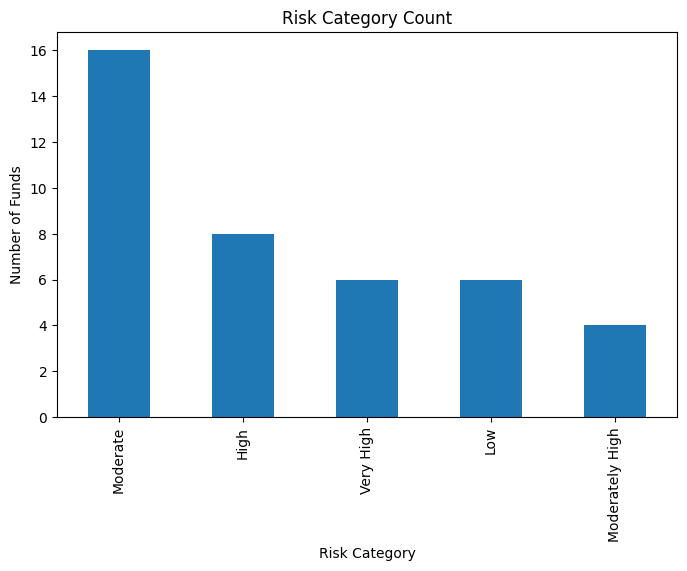

In [10]:
funds["risk_category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Category Count")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")

plt.show()

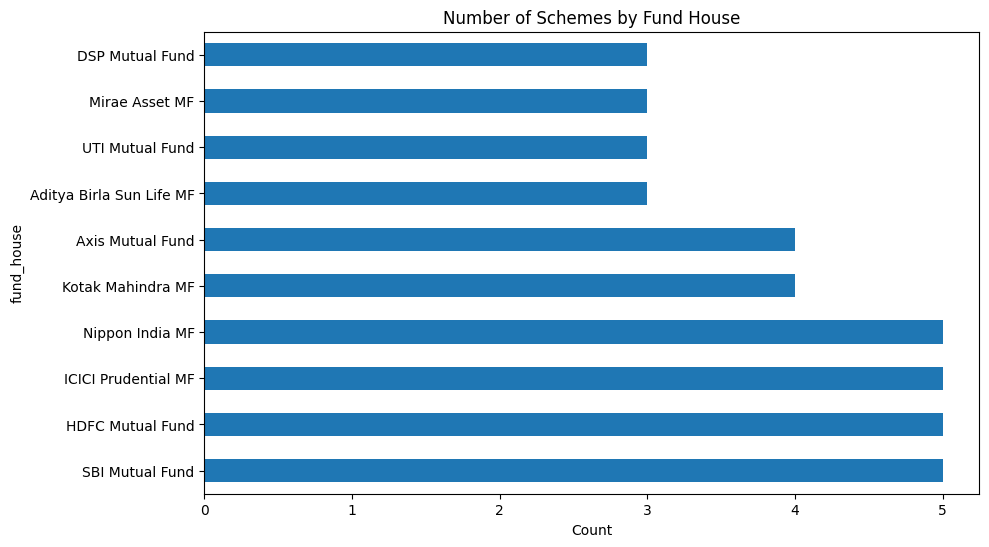

In [11]:
funds["fund_house"].value_counts().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Count")

plt.show()

In [13]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [16]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


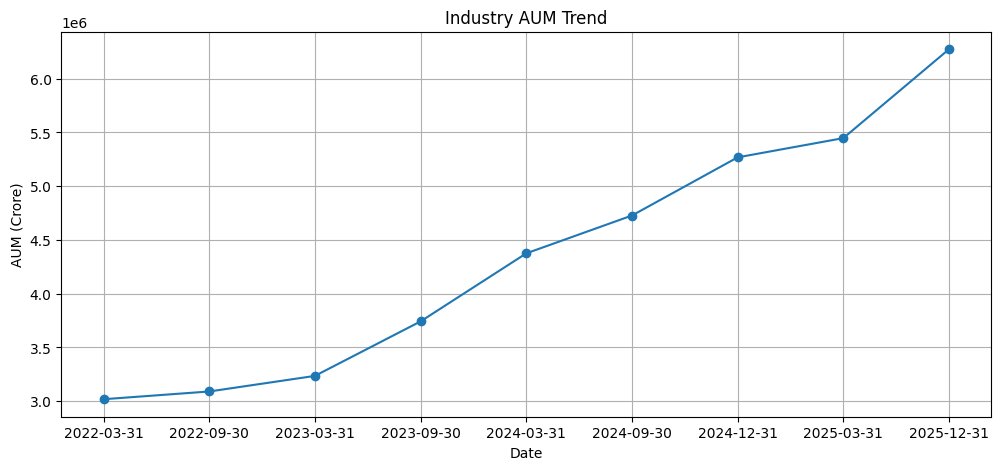

In [17]:
import matplotlib.pyplot as plt

aum.groupby("date")["aum_crore"].sum().plot(
    kind="line",
    figsize=(12,5),
    marker="o"
)

plt.title("Industry AUM Trend")
plt.xlabel("Date")
plt.ylabel("AUM (Crore)")
plt.grid(True)

plt.show()

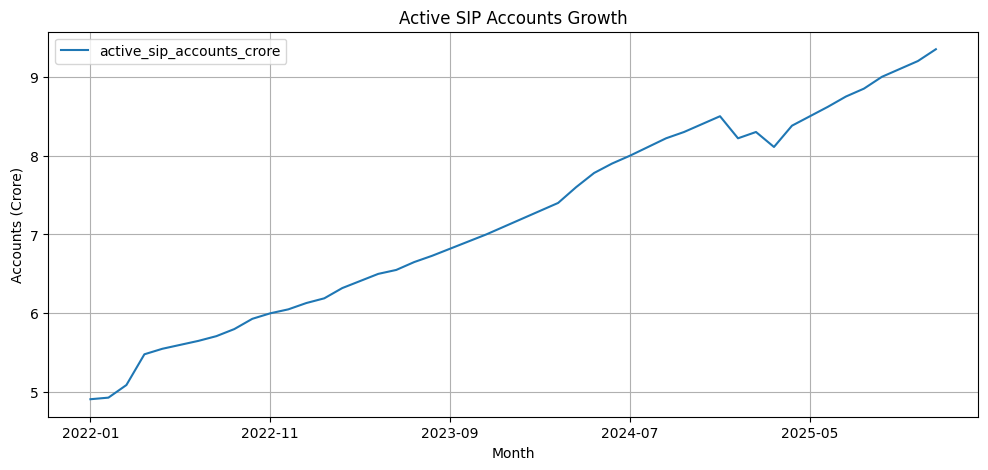

In [18]:
sip.plot(
    x="month",
    y="active_sip_accounts_crore",
    figsize=(12,5)
)

plt.title("Active SIP Accounts Growth")
plt.xlabel("Month")
plt.ylabel("Accounts (Crore)")
plt.grid(True)

plt.show()

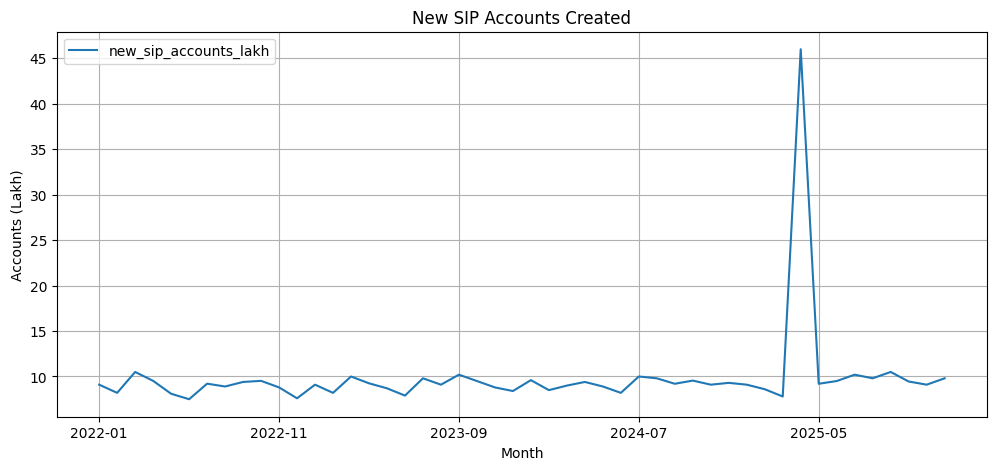

In [20]:
sip.plot(
    x="month",
    y="new_sip_accounts_lakh",
    figsize=(12,5)
)

plt.title("New SIP Accounts Created")
plt.xlabel("Month")
plt.ylabel("Accounts (Lakh)")
plt.grid(True)

plt.show()

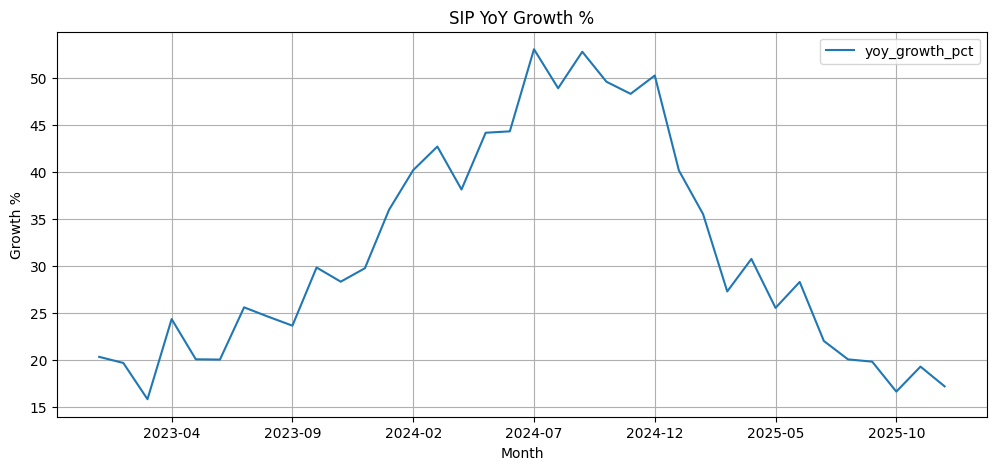

In [22]:
sip.plot(
    x="month",
    y="yoy_growth_pct",
    figsize=(12,5)
)

plt.title("SIP YoY Growth %")
plt.xlabel("Month")
plt.ylabel("Growth %")
plt.grid(True)

plt.show()

In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../database/mutual_fund.db")

funds = pd.read_sql("SELECT * FROM dim_fund", conn)
nav = pd.read_sql("SELECT * FROM fact_nav", conn)
aum = pd.read_sql("SELECT * FROM fact_aum", conn)
sip = pd.read_sql("SELECT * FROM fact_sip", conn)

conn.close()

print("Data Loaded Successfully")

Data Loaded Successfully


In [5]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [6]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [2]:
import pandas as pd

category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


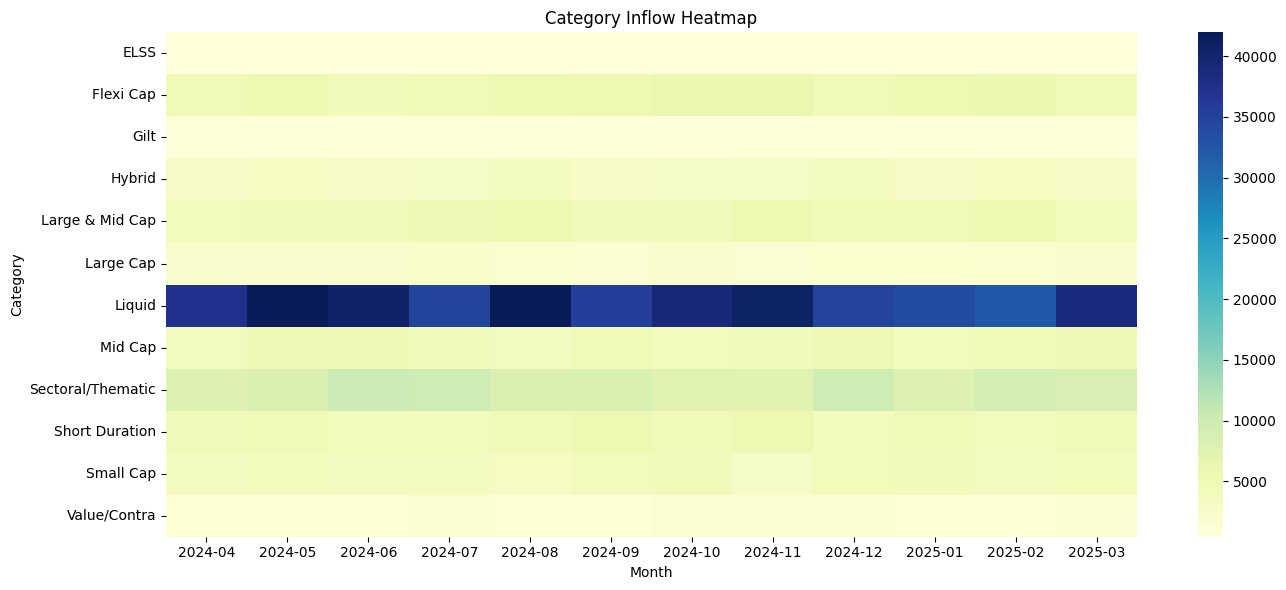

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
category = pd.read_csv("../data/raw/05_category_inflows.csv")

# Create pivot table
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)

# Plot heatmap
plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

# Save chart
plt.savefig("../reports/category_inflow_heatmap.png")

plt.show()

In [8]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current Folder:
c:\Users\varsh\OneDrive\Desktop\MutualFundAnalytics\notebooks

Files in current folder:
['eda.ipynb', 'risk_analytics.ipynb']


In [11]:
import pandas as pd

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


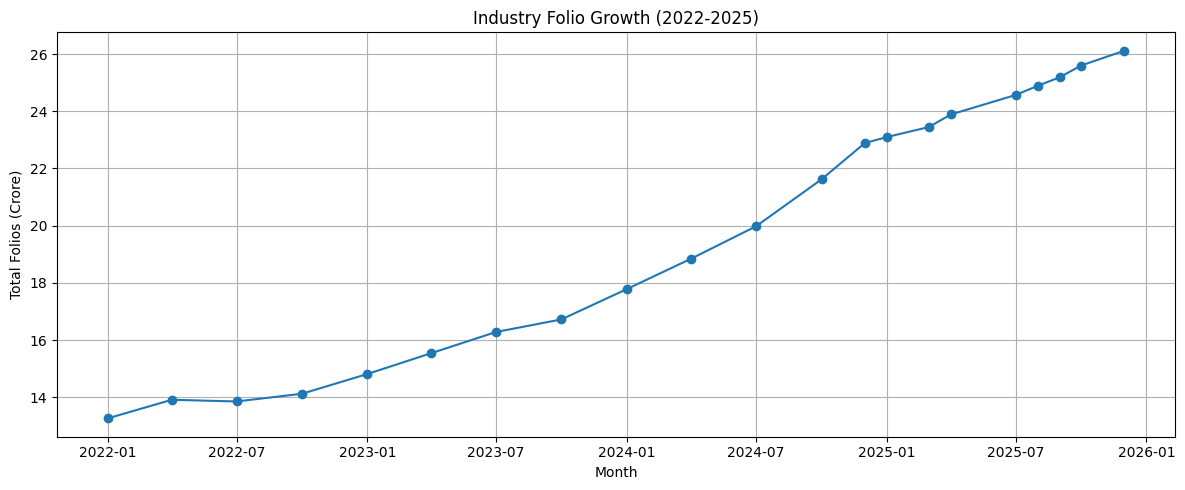

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

# Plot Total Folios
plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()

# Save chart
plt.savefig("../reports/folio_growth.png")

plt.show()

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.shape)
print(nav.columns)

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')


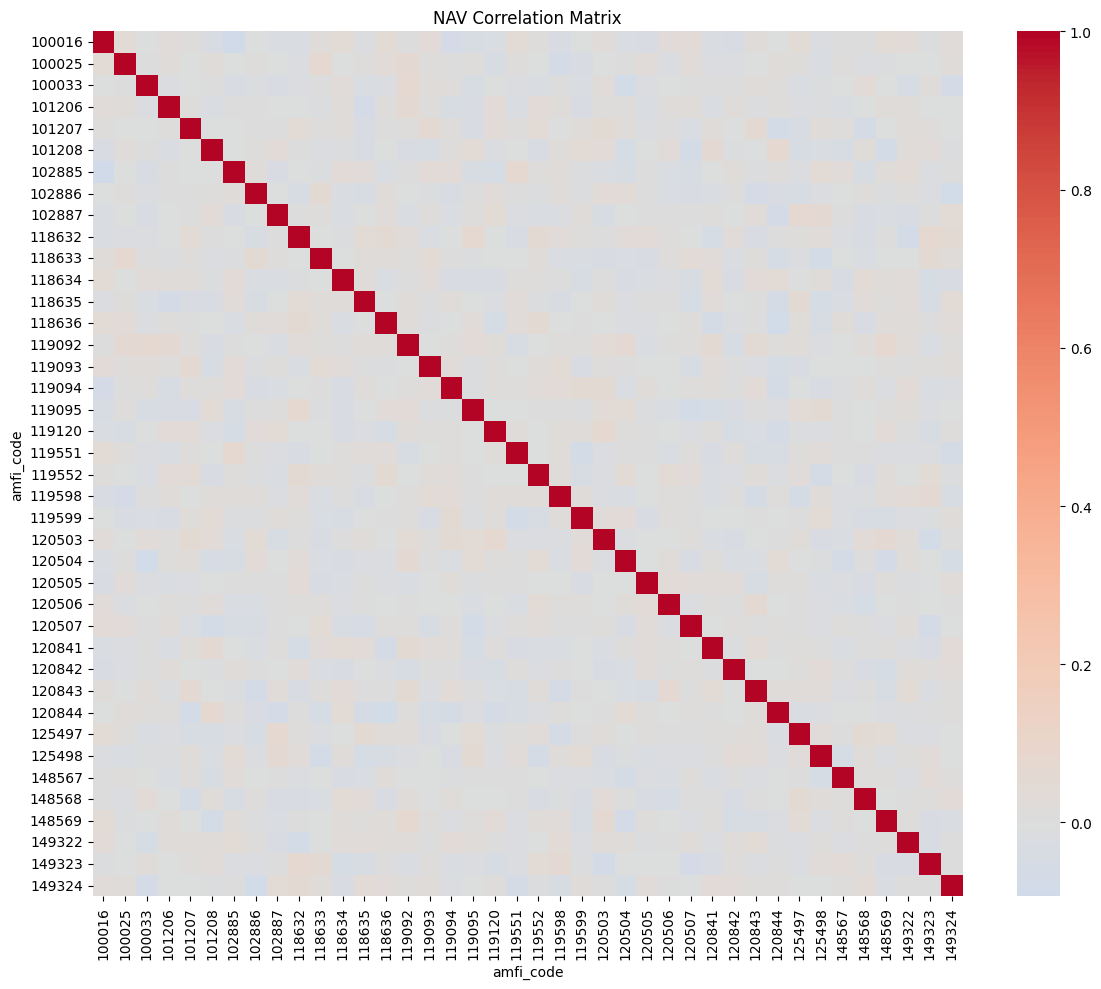

In [17]:
nav["date"] = pd.to_datetime(nav["date"])

pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Correlation Matrix")

plt.tight_layout()

plt.savefig("../reports/correlation_matrix.png")

plt.show()

In [19]:
import pandas as pd

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings.columns.tolist())
print(holdings.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


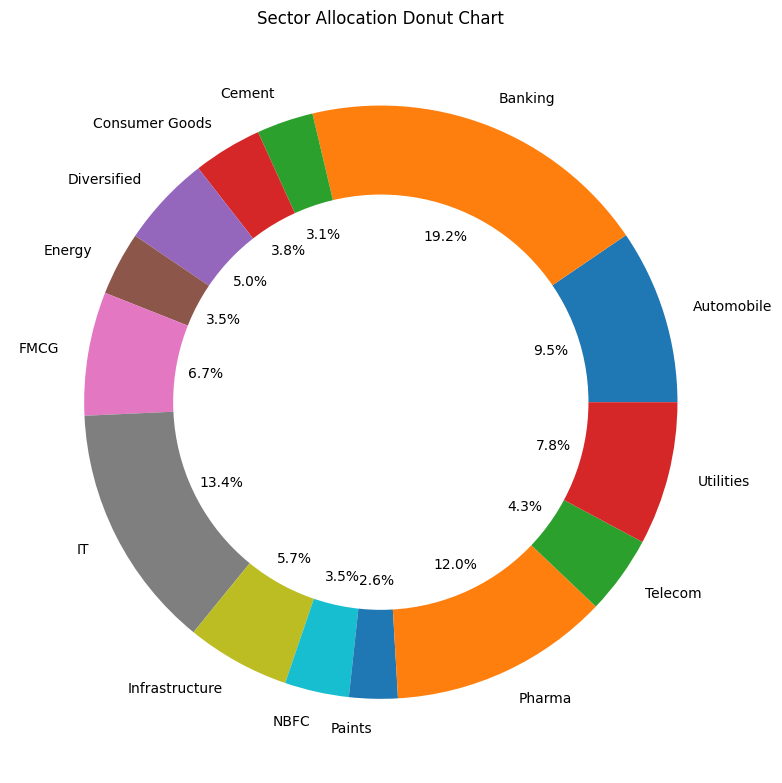

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Aggregate sector weights
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

# Plot donut chart
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

# Create donut hole
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Donut Chart")

plt.tight_layout()

# Save chart
plt.savefig("../reports/sector_allocation_donut.png")

plt.show()

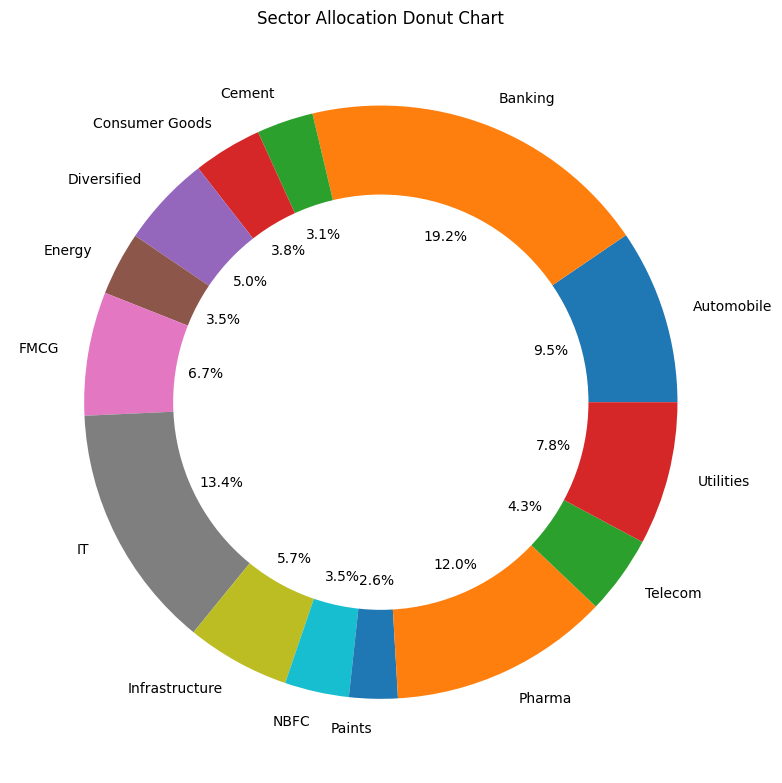

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Donut Chart")

plt.tight_layout()

plt.savefig("../reports/sector_allocation_donut.png")

plt.show()

## Key Findings

1. SIP inflows increased steadily from 2022 to 2025.
2. SBI Mutual Fund has highest AUM.
3. Equity funds dominate category inflows.
4. Large-cap funds show lower drawdowns.
5. Folio count doubled over study period.
6. SIP participation increased significantly.
7. Most schemes have positive Sharpe ratios.
8. Risk-adjusted returns vary across categories.
9. Sector concentration exists in equity funds.
10. Correlation between large-cap funds is high.